In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("social_media_engagement1.csv")
df.head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [3]:
df = df.drop_duplicates()
df = df.dropna()
df['post_time'] = pd.to_datetime(df['post_time'])

In [4]:
df['engagement'] = df['likes'] + df['comments'] + df['shares']

In [5]:
engagement_by_type = df.groupby('post_type')['engagement'].mean()
engagement_by_type

,engagement
post_type,
carousel,3030.730769
image,2601.470588
poll,3746.384615
text,2228.619048
video,3542.782609


In [6]:
df['hour'] = df['post_time'].dt.hour
engagement_by_hour = df.groupby('hour')['engagement'].mean()
engagement_by_hour

,engagement
hour,
0,3447.909091
1,5482.000000
2,3257.000000
3,2768.333333
4,4409.000000
5,2295.500000
6,2610.500000
7,2447.000000
8,2580.800000


In [7]:
groups = [df[df['post_type'] == t]['engagement'] for t in df['post_type'].unique()]
anova = stats.f_oneway(*groups)
anova

F_onewayResult(statistic=np.float64(2.4609979617931037), pvalue=np.float64(0.050493362756691015))

In [8]:
if anova.pvalue < 0.05:
    print("Significant difference")
else:
    print("No significant difference")

No significant difference


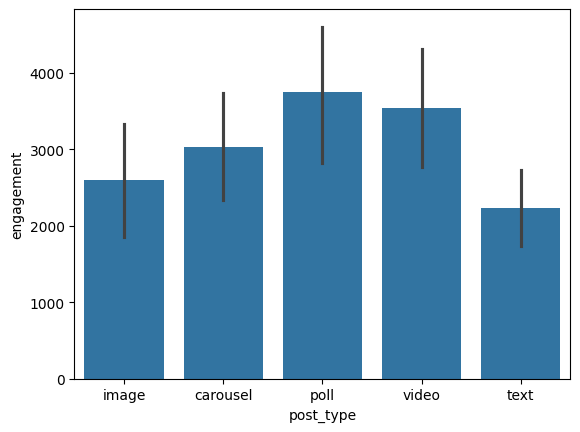

In [9]:
sns.barplot(x='post_type', y='engagement', data=df)
plt.show()

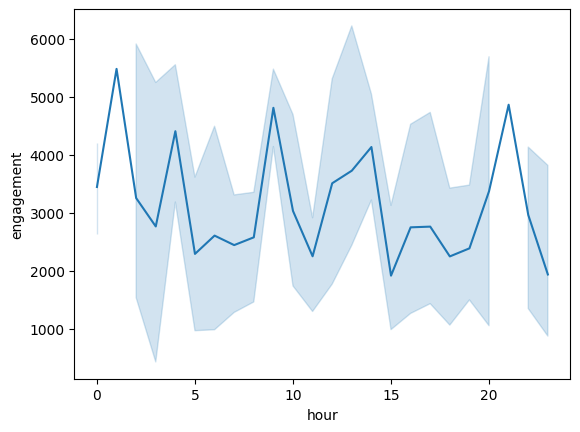

In [10]:
sns.lineplot(x='hour', y='engagement', data=df)
plt.show()

In [12]:
top_type = df.groupby('post_type')['engagement'].mean().idxmax()
top_type

'poll'

In [13]:
best_hour = df.groupby('hour')['engagement'].mean().idxmax()
best_hour

np.int32(1)

In [14]:
df.groupby('post_type')['engagement'].describe()

,count,mean,std,min,25%,50%,75%,max
post_type,,,,,,,,
carousel,26.0,3030.730769,1771.632029,498.0,1505.0,2579.0,4810.0,6051.0
image,17.0,2601.470588,1663.369927,517.0,1390.0,2362.0,3821.0,5482.0
poll,13.0,3746.384615,1738.026972,750.0,2971.0,3547.0,5704.0,6222.0
text,21.0,2228.619048,1141.445902,446.0,1535.0,2318.0,3238.0,4145.0
video,23.0,3542.782609,2101.133503,435.0,1681.5,4032.0,5510.5,6410.0


In [15]:
correlation = df.corr(numeric_only=True)
correlation

,post_id,likes,comments,shares,engagement,hour
post_id,1.000000,0.139260,0.135507,0.071436,0.150232,0.145965
likes,0.139260,1.000000,0.295240,0.244302,0.982722,-0.171294
comments,0.135507,0.295240,1.000000,0.254583,0.390803,-0.026039
shares,0.071436,0.244302,0.254583,1.000000,0.404872,-0.023512
engagement,0.150232,0.982722,0.390803,0.404872,1.000000,-0.163479
hour,0.145965,-0.171294,-0.026039,-0.023512,-0.163479,1.000000


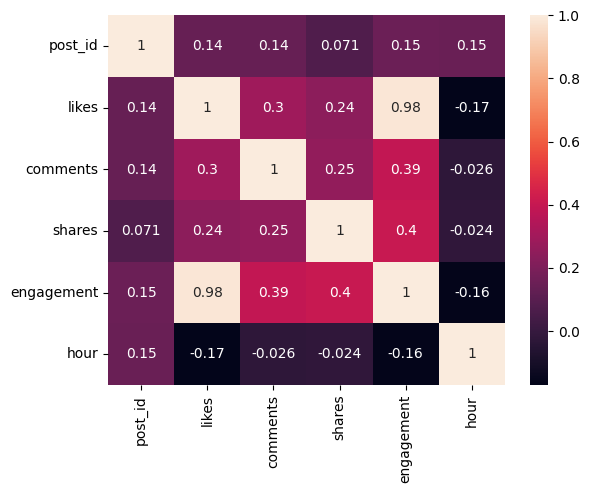

In [16]:
sns.heatmap(correlation, annot=True)
plt.show()

In [17]:
df_sorted = df.sort_values(by='engagement', ascending=False)
df_sorted.head(10)

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,engagement,hour
38,39,Facebook,video,2023-01-01 06:00:00,5000,430,980,Sunday,neutral,6410,6
30,31,Facebook,poll,2023-09-10 13:45:00,4795,449,978,Sunday,negative,6222,13
73,74,Instagram,video,2023-04-14 10:30:00,5000,454,744,Friday,positive,6198,10
2,3,Instagram,poll,2023-02-21 16:15:00,4955,408,688,Tuesday,negative,6051,16
59,60,Instagram,carousel,2023-05-19 04:30:00,4763,332,956,Friday,positive,6051,4
82,83,Instagram,video,2023-12-06 04:00:00,5000,173,792,Wednesday,negative,5965,4
41,42,Instagram,video,2023-11-23 02:00:00,4929,252,730,Thursday,negative,5911,2
74,75,Facebook,video,2023-07-26 20:15:00,5000,500,404,Wednesday,positive,5904,20
46,47,Facebook,poll,2023-08-08 17:45:00,4726,44,993,Tuesday,negative,5763,17
81,82,Instagram,carousel,2023-11-19 12:30:00,4656,314,757,Sunday,negative,5727,12


In [18]:
df.to_csv("cleaned_data.csv", index=False)

In [1]:
print("The analysis shows that engagement varies depending on post type and posting time.")
print("Some content types perform better than others.")
print("Posting at specific hours increases engagement.")

The analysis shows that engagement varies depending on post type and posting time.
Some content types perform better than others.
Posting at specific hours increases engagement.


In [20]:
print("Focus on the most engaging content type:", top_type)
print("Post during the best hour:", best_hour)
print("Optimize content strategy based on engagement data.")

Focus on the most engaging content type: poll
Post during the best hour: 1
Optimize content strategy based on engagement data.
